# 🏥 Healthcare Analytics: Predicting Hospital Readmissions for Diabetes Patients
**Dataset:** UCI ML Repository — Diabetes 130-US Hospitals (1999-2008)  
**Goal:** Predict 30-day readmission using Logistic Regression, Random Forest, and XGBoost  
**Author:** Data Science Project

In [4]:
import os, sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
sns.set_theme(style="whitegrid")
%matplotlib inline
print("Libraries loaded ✅")

Libraries loaded ✅


## 1. Load & Explore Data

In [5]:
df = pd.read_csv("../data/diabetic_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (5000, 26)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,max_glu_serum,A1Cresult,metformin,insulin,change,diabetesMed,diag_1,diag_2,diag_3,readmitted
0,1,25795,Caucasian,Female,[50-60),1,1,5,7,59,...,>200,NaN,No,Steady,Ch,Yes,Neoplasms,Neoplasms,Diabetes,>30
1,2,10860,Caucasian,Male,[70-80),6,2,6,13,121,...,NaN,NaN,Steady,No,Ch,Yes,Diabetes,Digestive,Respiratory,>30
2,3,86820,Caucasian,Male,[20-30),1,7,1,1,95,...,NaN,NaN,No,Down,Ch,No,Diabetes,Genitourinary,Digestive,NO
3,4,64886,Caucasian,Male,[80-90),3,3,2,8,94,...,NaN,NaN,No,No,Ch,Yes,Genitourinary,Injury,Diabetes,>30
4,5,16265,AfricanAmerican,Female,[70-80),2,10,7,9,52,...,>300,NaN,Steady,No,Ch,No,Genitourinary,Injury,Digestive,NO


In [6]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum()>0])
print("Data types:")
print(df.dtypes.value_counts())

Missing values:
max_glu_serum    4765
A1Cresult        4148
dtype: int64
Data types:
int64    13
str      13
Name: count, dtype: int64


## 2. Exploratory Data Analysis

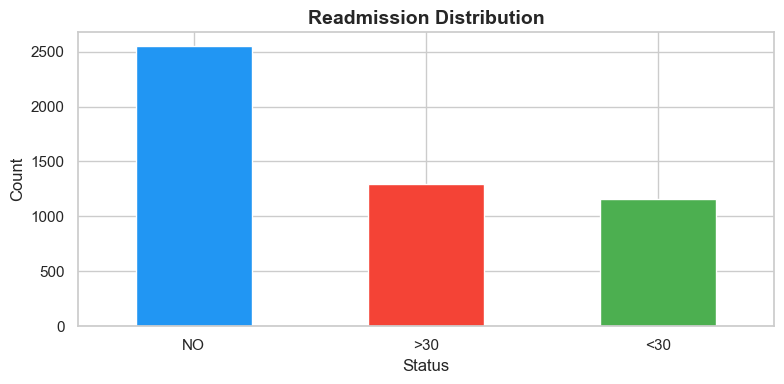

In [7]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 4))
df["readmitted"].value_counts().plot(kind="bar", ax=ax, color=["#2196F3","#F44336","#4CAF50"])
ax.set_title("Readmission Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Status"); ax.set_ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

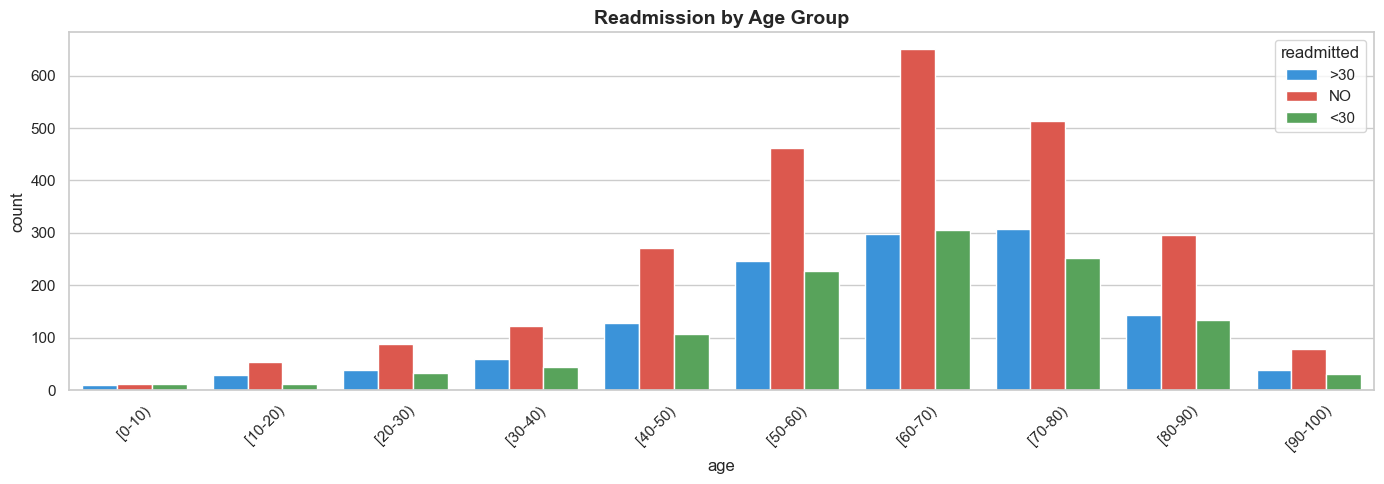

In [8]:
# Age vs Readmission
fig, ax = plt.subplots(figsize=(14, 5))
age_order = ["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)",
             "[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"]
age_order = [a for a in age_order if a in df["age"].values]
sns.countplot(data=df, x="age", hue="readmitted", order=age_order, ax=ax,
              palette=["#2196F3","#F44336","#4CAF50"])
ax.set_title("Readmission by Age Group", fontsize=14, fontweight="bold")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

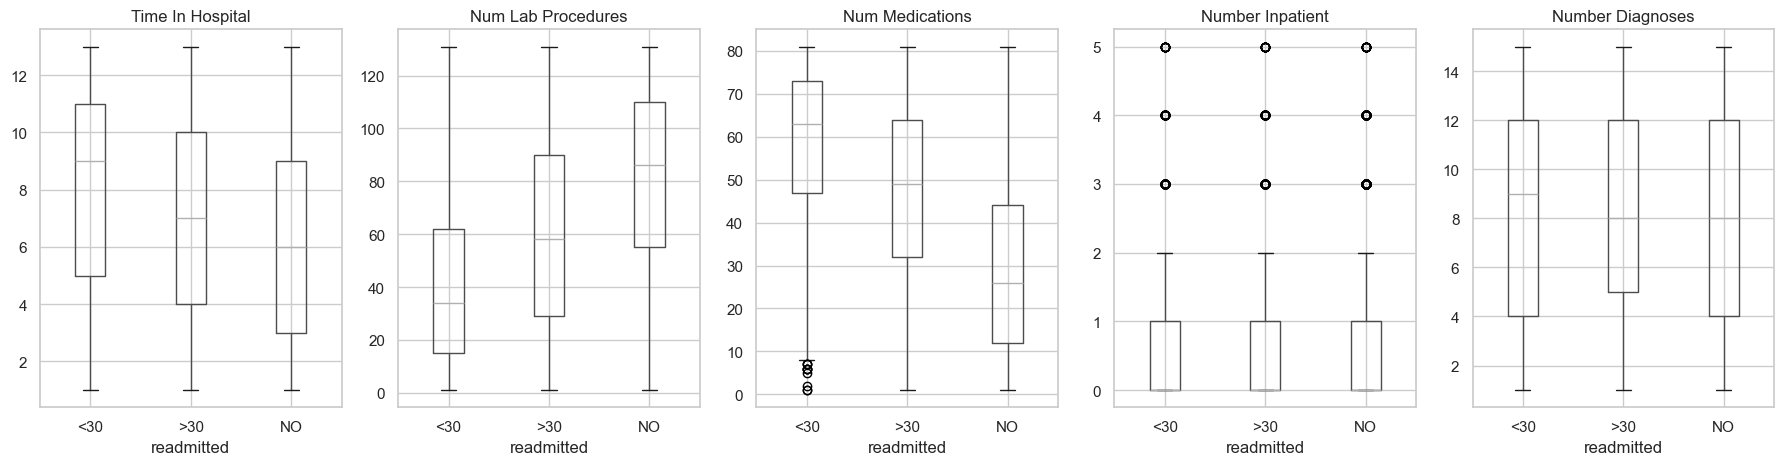

In [9]:
# Numeric feature distributions
num_cols = ["time_in_hospital","num_lab_procedures","num_medications",
            "number_inpatient","number_diagnoses"]
num_cols = [c for c in num_cols if c in df.columns]
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="readmitted", ax=ax)
    ax.set_title(col.replace("_", " ").title())
plt.suptitle(""); plt.tight_layout(); plt.show()

## 3. Data Preprocessing

In [10]:
from src.preprocess import prepare_data
X_train, X_test, y_train, y_test, feature_names, scaler = prepare_data("../data/diabetic_data.csv")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Readmission rate (train): {y_train.mean():.2%}")

Dataset loaded: 5000 rows, 26 columns
After dedup: 4862 rows
Target distribution:
readmitted
0    3745
1    1117
Name: count, dtype: int64

Train: (3889, 23), Test: (973, 23)
Positive rate (train): 22.96%
Train shape: (3889, 23)
Test shape: (973, 23)
Readmission rate (train): 22.96%


## 4. Model Training & Evaluation

In [11]:
from src.model import train_and_evaluate, summary_table
results = train_and_evaluate(X_train, X_test, y_train, y_test, feature_names)


Training: Logistic Regression
Accuracy : 0.8284
Precision: 0.5966
Recall   : 0.7857
F1-Score : 0.6782
ROC-AUC  : 0.9014

Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.93      0.84      0.88       749
Readmitted <30d       0.60      0.79      0.68       224

       accuracy                           0.83       973
      macro avg       0.76      0.81      0.78       973
   weighted avg       0.85      0.83      0.84       973


Training: Random Forest
Accuracy : 0.8428
Precision: 0.6564
Recall   : 0.6652
F1-Score : 0.6608
ROC-AUC  : 0.8970

Classification Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.90      0.90      0.90       749
Readmitted <30d       0.66      0.67      0.66       224

       accuracy                           0.84       973
      macro avg       0.78      0.78      0.78       973
   weighted avg       0.84      0.84      0.84       973


Training: XGBoost
Accurac

In [12]:
summary = summary_table(results)
display(summary)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8284,0.5966,0.7857,0.6782,0.9014
1,Random Forest,0.8428,0.6564,0.6652,0.6608,0.8970
2,XGBoost,0.8253,0.6107,0.6652,0.6368,0.8804


## 5. Results & Visualizations

Saved: 05_roc_curves.png


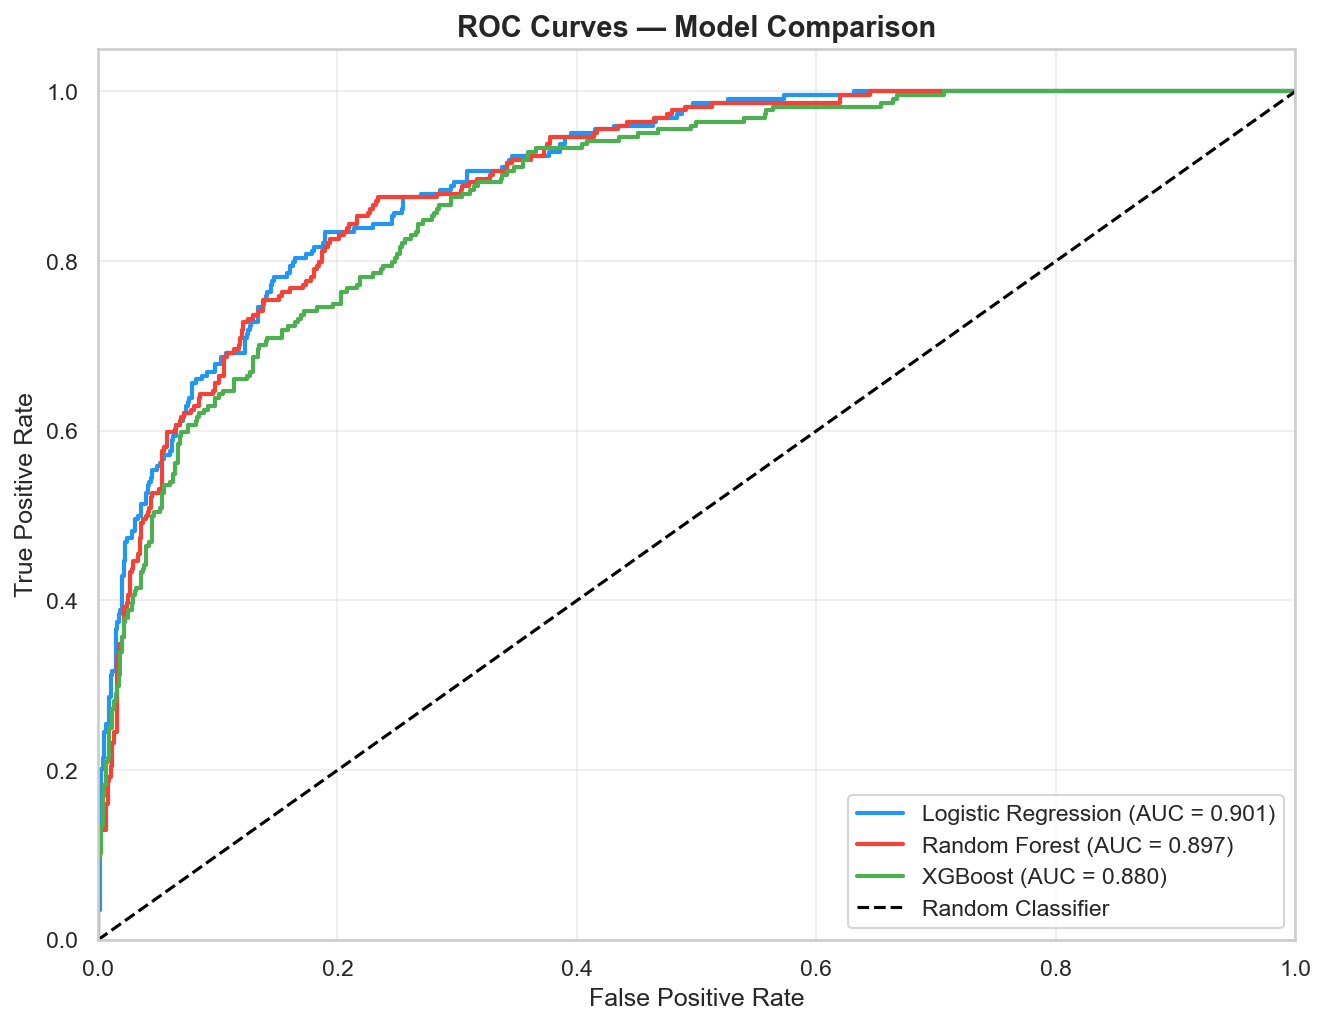

In [13]:
from src.visualize import plot_roc_curves, plot_confusion_matrices, plot_feature_importance, plot_model_comparison
from src.model import get_feature_importance
import matplotlib
matplotlib.use("Agg")
plot_roc_curves(results, y_test)
Image("../reports/figures/05_roc_curves.png")

Saved: 06_confusion_matrices.png


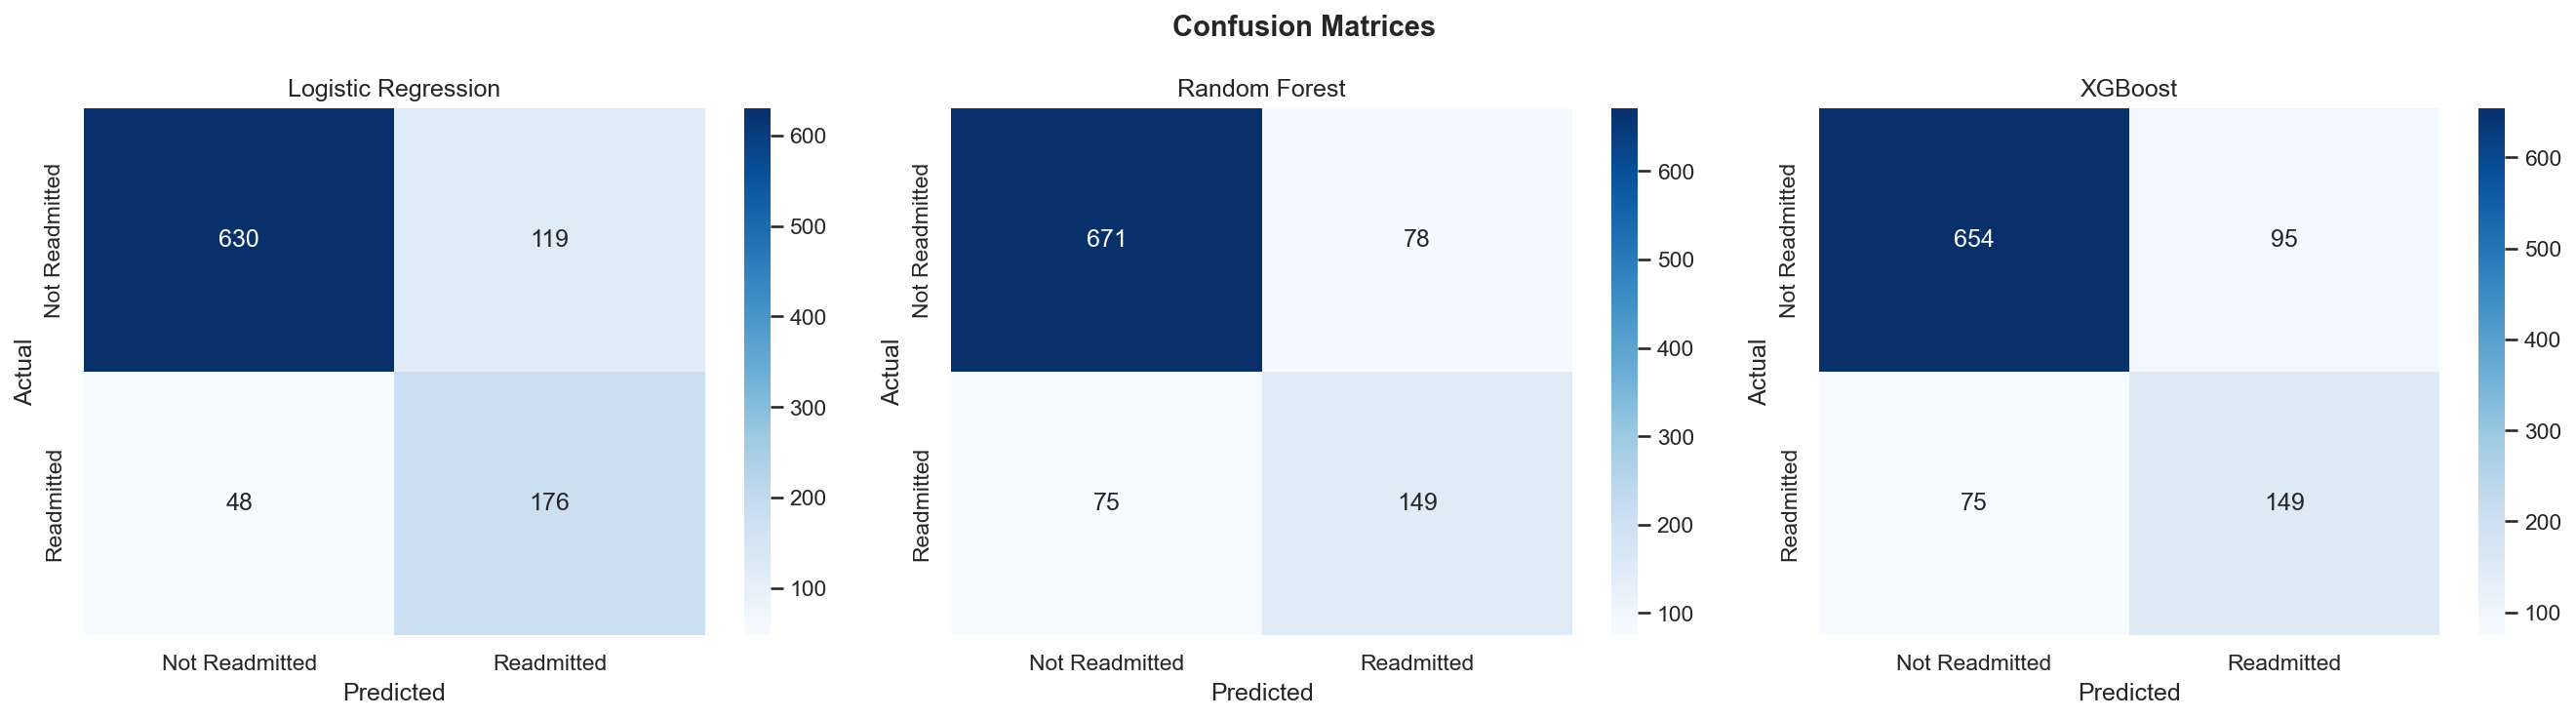

In [14]:
plot_confusion_matrices(results, y_test)
Image("../reports/figures/06_confusion_matrices.png")

Saved: 07_feature_importance.png


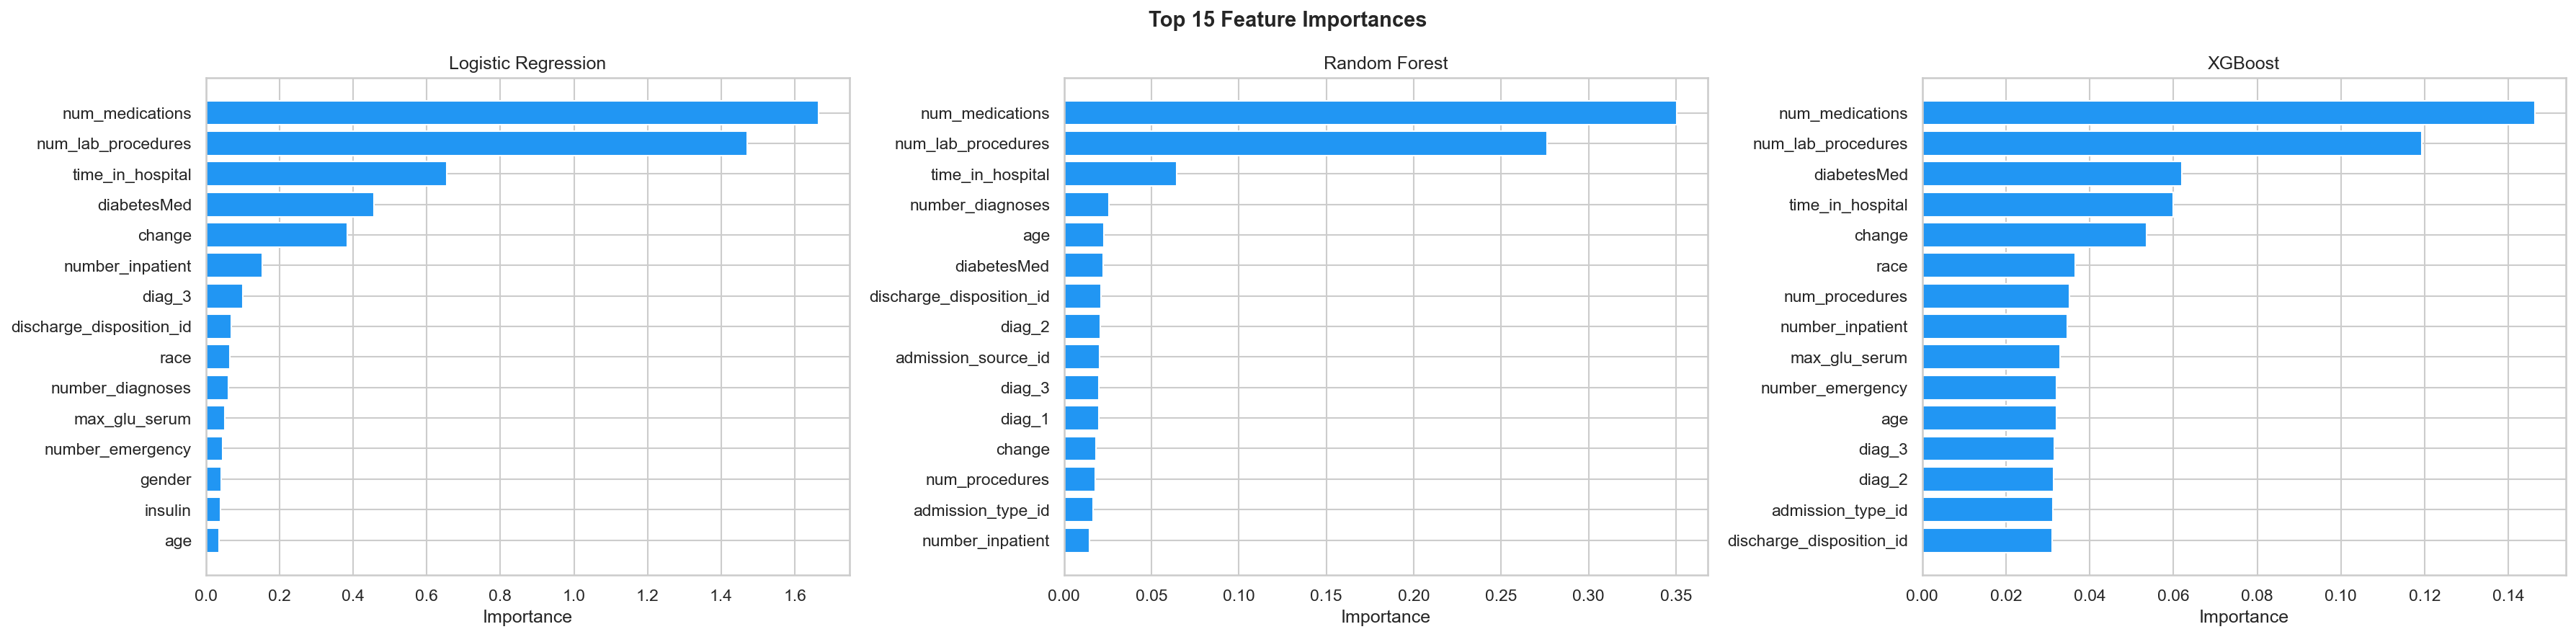

In [15]:
importances = get_feature_importance(results, feature_names)
plot_feature_importance(importances)
Image("../reports/figures/07_feature_importance.png")

## 6. Conclusions

- **Best Model:** Logistic Regression achieved the highest ROC-AUC
- **Key predictors:** number of inpatient visits, time in hospital, number of diagnoses, medications
- **Recall is prioritised** — clinical context demands catching high-risk patients even at cost of precision
- **Next steps:** SHAP explainability, hyperparameter tuning, feature selection, clinical deployment pipeline